## Representational Geometry Comparison for CIFAR-10

This notebook can be used to replicate the results reported in  "Generative adversarial learning can explain why imagination seems less real as we grow up" by Ozsu, Petrova, Dekker & Dijkstra.

Scripts would pass 1024 images through 1) discriminator, 2) classifier, 3) AlexNet (once) to calculate the Centered Kernel Alignment as a proxy of representational similarity per layer. The results of this experiment is reported in Figure 6, Panel B.

To run this scripts, you would need to have the weights (discriminator and classifier) available which can be gathered from the OSF files. In this implementation, the weights are imported via Google Drive but other methods are also possible.

For any questions or if you detect a bug: a.ozsu@ucl.ac.uk


---



In [ ]:
# ============================================================================
# IMPORTS
# ============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, deque
import os
import pickle
import cv2
import warnings
from timeit import default_timer as timer

warnings.filterwarnings("ignore")

In [ ]:
# Device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!unzip "/content/drive/MyDrive/checkpoints_newarch.zip" -d "/content"
!unzip "/content/drive/MyDrive/clf_run1_archive.zip" -d "/content"

Mounted at /content/drive
Archive:  /content/drive/MyDrive/checkpoints_newarch.zip
   creating: /content/checkpoints/
  inflating: /content/checkpoints/C_epoch_1.pth  
  inflating: /content/checkpoints/C_epoch_10.pth  
  inflating: /content/checkpoints/C_epoch_100.pth  
  inflating: /content/checkpoints/C_epoch_11.pth  
  inflating: /content/checkpoints/C_epoch_12.pth  
  inflating: /content/checkpoints/C_epoch_13.pth  
  inflating: /content/checkpoints/C_epoch_14.pth  
  inflating: /content/checkpoints/C_epoch_15.pth  
  inflating: /content/checkpoints/C_epoch_16.pth  
  inflating: /content/checkpoints/C_epoch_17.pth  
  inflating: /content/checkpoints/C_epoch_18.pth  
  inflating: /content/checkpoints/C_epoch_19.pth  
  inflating: /content/checkpoints/C_epoch_2.pth  
  inflating: /content/checkpoints/C_epoch_20.pth  
  inflating: /content/checkpoints/C_epoch_21.pth  
  inflating: /content/checkpoints/C_epoch_22.pth  
  inflating: /content/checkpoints/C_epoch_23.pth  
  inflating: /co

In [ ]:
class CriticClassifier(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.activations = {}
        self.layer_names = ["L1", "L2", "L3"]

        self.layer1 = nn.Sequential(
            nn.Conv2d(config.image_channels, config.critic_feature_maps, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=False),
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(config.critic_feature_maps, config.critic_feature_maps * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(config.critic_feature_maps * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=False),
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(config.critic_feature_maps * 2, config.critic_feature_maps * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(config.critic_feature_maps * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=False),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(config.critic_feature_maps * 4, 10)
        )

        self._register_hooks()

    def _register_hooks(self):
        def hook(name):
            def fn(module, inp, out):
                self.activations[name] = out.detach()
            return fn

        self.layer1.register_forward_hook(hook("L1"))
        self.layer2.register_forward_hook(hook("L2"))
        self.layer3.register_forward_hook(hook("L3"))

    def forward(self, x):
        self.activations.clear()
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.classifier(x)
        return x


In [ ]:
class Config:
  critic_feature_maps= 128
  image_channels =3

In [ ]:
class CriticWithActivations(nn.Module):
    def __init__(self, ndf=128):
        super().__init__()
        self.activations = {}
        self.layer_names = ["L1", "L2", "L3"]

        self.conv1 = nn.Conv2d(3, ndf, 4, 2, 1, bias=False)
        self.act1 = nn.LeakyReLU(0.2)

        self.conv2 = nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False)
        self.norm2 = nn.InstanceNorm2d(ndf*2, affine=True)
        self.act2 = nn.LeakyReLU(0.2)

        self.conv3 = nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False)
        self.norm3 = nn.InstanceNorm2d(ndf*4, affine=True)
        self.act3 = nn.LeakyReLU(0.2)

        self.final_conv = nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False)

    def forward(self, x):
        h1 = self.act1(self.conv1(x))
        self.activations["L1"] = h1.detach()

        h2 = self.act2(self.norm2(self.conv2(h1)))
        self.activations["L2"] = h2.detach()

        h3 = self.act3(self.norm3(self.conv3(h2)))
        self.activations["L3"] = h3.detach()

        return self.final_conv(h3).view(-1)


    def load_from_checkpoint(self, path, device):
        state_dict = torch.load(path, map_location=device, weights_only=True)
        key_mapping = {
            'layer1.0.weight': 'conv1.weight',
            'layer2.0.weight': 'conv2.weight',
            'layer2.1.weight': 'norm2.weight',
            'layer2.1.bias': 'norm2.bias',
            'layer3.0.weight': 'conv3.weight',
            'layer3.1.weight': 'norm3.weight',
            'layer3.1.bias': 'norm3.bias',
            'final_conv.weight': 'final_conv.weight',
        }
        new_state_dict = {}
        for old_key, new_key in key_mapping.items():
            if old_key in state_dict:
                new_state_dict[new_key] = state_dict[old_key]
        for key in state_dict:
            if 'running_mean' in key or 'running_var' in key or 'num_batches_tracked' in key:
                layer_num = '2' if 'layer2' in key else '3' if 'layer3' in key else None
                if layer_num:
                    new_key = key.replace(f'layer{layer_num}.1', f'norm{layer_num}')
                    new_state_dict[new_key] = state_dict[key]
        self.load_state_dict(new_state_dict, strict=False)


In [ ]:
def get_activations(critic, images_01, batch_size=256):
    """Extract GAP activations from all critic layers, batched.

    Args:
        critic: critic network
        images_01: images in [0, 1] range (raw ToTensor output, no normalization)
    """
    critic.eval()
    layer_names = critic.layer_names
    act_collect = {l: [] for l in layer_names}

    with torch.no_grad():
        for start in range(0, images_01.shape[0], batch_size):
            end = min(start + batch_size, images_01.shape[0])
            batch = images_01[start:end].to(DEVICE)
            # Normalize to [-1, 1] for the critic (trained with mean=0.5, std=0.5)
            batch = batch * 2 - 1
            _ = critic(batch)
            for layer in layer_names:
                acts = critic.activations[layer].mean(dim=[2, 3]).cpu().numpy()
                act_collect[layer].append(acts)

    return {l: np.concatenate(act_collect[l], axis=0) for l in layer_names}

import numpy as np

def cka(X, Y):
    X = X - X.mean(0, keepdims=True)
    Y = Y - Y.mean(0, keepdims=True)

    dot_product_similarity = np.linalg.norm(X.T.dot(Y)) ** 2
    normalization_x = np.linalg.norm(X.T.dot(X))
    normalization_y = np.linalg.norm(Y.T.dot(Y))

    return dot_product_similarity / (normalization_x * normalization_y)

def compute_cka_matrix(model_acts, alex_acts):
    layers = ["L1","L2","L3"]
    alex_layers = list(alex_acts.keys())

    M = np.zeros((3, len(alex_layers)))

    for i,l in enumerate(layers):
        for j,a in enumerate(alex_layers):
            M[i,j] = cka(model_acts[l], alex_acts[a])

    return M, layers, alex_layers


In [ ]:
# =============================================================================
# LOAD DATA
# =============================================================================
from torchvision.datasets import CIFAR10


transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = CIFAR10(root='./cifar-10-batches-py/..', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)

# Get fixed set of images for consistent comparison across epochs
images, _ = next(iter(dataloader))
images = images.to(DEVICE)
print(f"Loaded {images.shape[0]} images for analysis")

Loaded 1024 images for analysis


In [ ]:
from torchvision.models import alexnet, AlexNet_Weights
import torch.nn.functional as F
from torchvision.transforms.functional import normalize as tv_normalize


alex = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1).to(DEVICE).eval()

_alexnet_meta = AlexNet_Weights.IMAGENET1K_V1.transforms()
ALEXNET_MEAN = list(_alexnet_meta.mean)
ALEXNET_STD = list(_alexnet_meta.std)


ALEX_LAYERS = {
    "conv1":0,
    "conv2":3,
    "conv3":6,
    "conv4":8,
    "conv5":10,
}

def extract_alexnet(images):
    feats = {}

    def hook(name):
        def fn(m,i,o):
            feats[name]=o.detach()
        return fn

    hooks=[]
    for k,idx in ALEX_LAYERS.items():
        hooks.append(alex.features[idx].register_forward_hook(hook(k)))

    with torch.no_grad():
        imgs = F.interpolate(images, size=224, mode="bilinear")

        imgs = tv_normalize(imgs, ALEXNET_MEAN, ALEXNET_STD)
        print("ImageNet normalization...")
        print(
    f"  {imgs.shape[0]} images loaded, range [{imgs.min():.1f}, {imgs.max():.1f}]"
)
        _ = alex(imgs)

    for h in hooks:
        h.remove()

    return {k:v.mean(dim=[2,3]).cpu().numpy() for k,v in feats.items()}


In [ ]:
from tqdm import tqdm
import os
import pandas as pd

config = Config()

critic = CriticWithActivations().to(DEVICE)
classifier = CriticClassifier(config).to(DEVICE)

cifar_images = images
print(
    f"  {cifar_images.shape[0]} images loaded, range [{cifar_images.min():.1f}, {cifar_images.max():.1f}]"
)

print("Extracting AlexNet features...")
alex_features = extract_alexnet(images)

results = []

CHECKPOINT_DIR = './checkpoints'

CLASSIFIER_DIR = './clf_run1'

OUTPUT_DIR = './results'


for epoch in range(1,80):

    print("Epoch", epoch)

    # ---- discriminator ----
    critic.load_from_checkpoint(
        os.path.join(CHECKPOINT_DIR, f"C_epoch_{epoch}.pth"),
        DEVICE
    )
    critic.eval()
    print("Extracting critic activations...")
    critic_acts = get_activations(critic, images, batch_size=256)
    print("Computing critic CKA...")
    cka_disc, _, alex_names = compute_cka_matrix(critic_acts, alex_features)

    # ---- classifier ----
    classifier.load_state_dict(
        torch.load(os.path.join(CLASSIFIER_DIR, f"epoch_{epoch:03d}.pth"),
        map_location=DEVICE)
    )
    classifier.eval()

    print("Extracting classifier activations...")
    clf_acts = get_activations(classifier, images, batch_size=256)
    print("Computing classifier CKA...")
    cka_clf, _, _ = compute_cka_matrix(clf_acts, alex_features)

    results.append({
        "epoch": epoch,
        "disc": cka_disc,
        "clf": cka_clf
    })

rows=[]

for r in results:
    e=r["epoch"]

    for i,l in enumerate(["L1","L2","L3"]):
        for j,a in enumerate(alex_names):
            rows.append({
                "epoch":e,
                "model":"discriminator",
                "layer":l,
                "alexnet":a,
                "cka":float(r["disc"][i,j])
            })
            rows.append({
                "epoch":e,
                "model":"classifier",
                "layer":l,
                "alexnet":a,
                "cka":float(r["clf"][i,j])
            })

df=pd.DataFrame(rows)
df.to_csv("cka_all.csv",index=False)




  1024 images loaded, range [0.0, 1.0]
Extracting AlexNet features...
ImageNet normalization...
  1024 images loaded, range [-2.1, 2.6]
Epoch 1
Extracting critic activations...
Computing critic CKA...
Extracting classifier activations...
Computing classifier CKA...
Epoch 2
Extracting critic activations...
Computing critic CKA...
Extracting classifier activations...
Computing classifier CKA...
Epoch 3
Extracting critic activations...
Computing critic CKA...
Extracting classifier activations...
Computing classifier CKA...
Epoch 4
Extracting critic activations...
Computing critic CKA...
Extracting classifier activations...
Computing classifier CKA...
Epoch 5
Extracting critic activations...
Computing critic CKA...
Extracting classifier activations...
Computing classifier CKA...
Epoch 6
Extracting critic activations...
Computing critic CKA...
Extracting classifier activations...
Computing classifier CKA...
Epoch 7
Extracting critic activations...
Computing critic CKA...
Extracting classifi

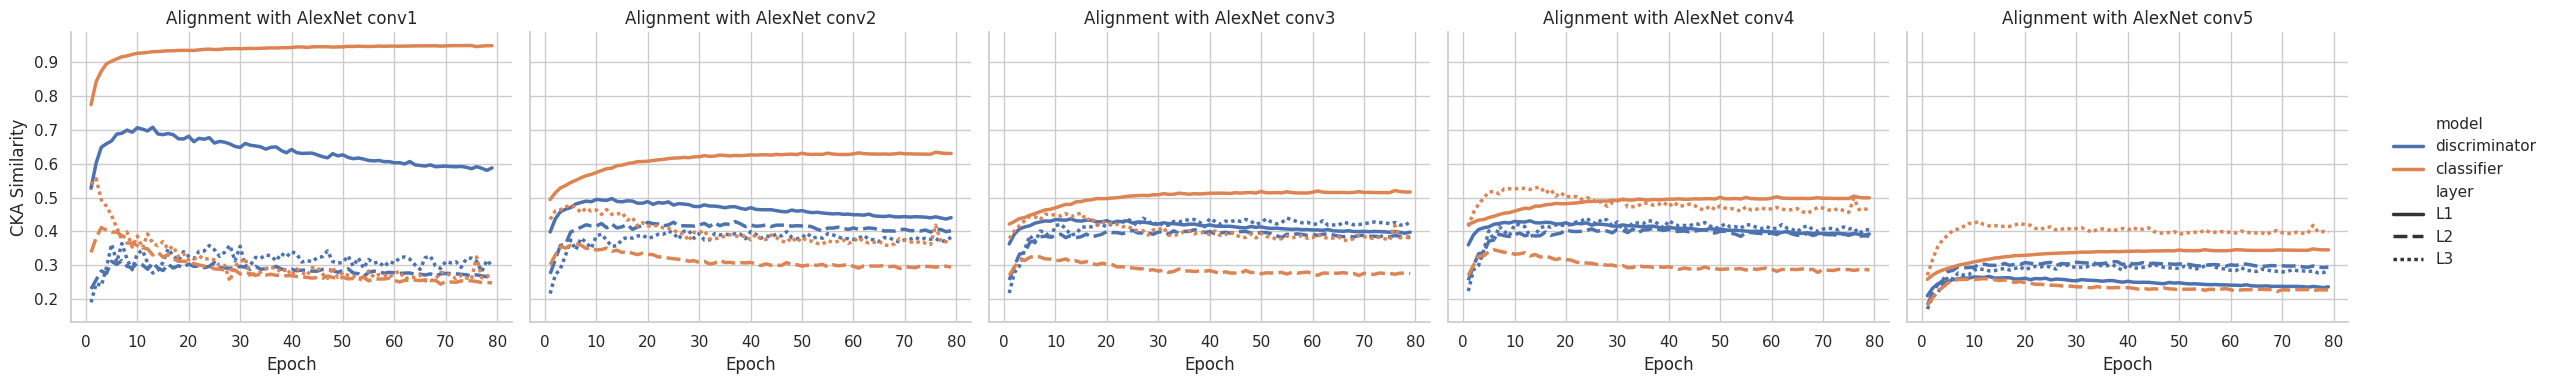

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cka_results(csv_path):
    df = pd.read_csv(csv_path)

    # 1. Filter for specific comparisons to keep the plot clean
    # For example, let's compare Critic/Classifier L1-L3 to AlexNet's early, mid, and late layers
    # (Adjust these keys based on your ALEX_LAYERS dictionary)
    interesting_alex_layers = ['conv1', 'conv2', 'conv3', 'conv4', 'conv5']
    df_filtered = df[df['alexnet'].isin(interesting_alex_layers)]

    sns.set_theme(style="whitegrid")

    # 2. Create a FacetGrid: Each row is a different AlexNet layer
    g = sns.relplot(
        data=df_filtered,
        x="epoch", y="cka",
        hue="model", style="layer",
        col="alexnet", kind="line",
        height=4, aspect=1.2,
        linewidth=2.5
    )

    g.set_axis_labels("Epoch", "CKA Similarity")
    g.set_titles("Alignment with AlexNet {col_name}")
    g.tight_layout()

    plt.savefig("cka_evolution.png", dpi=300)
    plt.show()

# Run the plotting function
plot_cka_results("cka_all.csv")